This notebook will set up a word2vec-style embedding based on the text of Moby Dick. See this blog post for a walkthrough of the concepts being used here: https://jalammar.github.io/illustrated-word2vec/

In [1]:
import torch
import torch.nn.functional as F
import re
import tqdm
import matplotlib.pyplot as plt

# load moby dick
with open('data/pg2701.txt', 'r') as fobj:
    mobydick = fobj.read()
mobydick = mobydick.split('\n')

# find the first line of the actual text
for i, line in enumerate(mobydick):
    if "Call me Ishmael" in line:
        break
all_text = ' '.join(mobydick[i:])
all_words = re.findall('[a-zA-Z]+', all_text)
all_words_lower = list(map(lambda word: word.lower(), all_words))
N = len(all_words_lower)

# create a vocabulary: list of unique words
vocab = list(set(all_words_lower))
V = len(vocab)

# assign each word to an integer from 1...V=len(vocab), and vice versa
w_to_i = {word: i for i, word in enumerate(vocab)}
i_to_w = {i: word for i, word in enumerate(vocab)}

# convert all letters to integers
all_integers = [w_to_i[word] for word in all_words_lower]

In [2]:
all_integers

[2989,
 12929,
 10446,
 15311,
 9406,
 4122,
 7159,
 5118,
 7673,
 4460,
 14206,
 3932,
 794,
 16775,
 16232,
 4712,
 11708,
 6360,
 11772,
 4331,
 9701,
 13596,
 15955,
 13169,
 12929,
 5605,
 16087,
 16495,
 5922,
 16495,
 2350,
 14325,
 15046,
 11953,
 794,
 4331,
 1674,
 4950,
 984,
 3645,
 2535,
 4950,
 12390,
 3131,
 334,
 11953,
 14155,
 16495,
 13876,
 2535,
 8490,
 6885,
 4950,
 7055,
 4331,
 13255,
 4950,
 12118,
 9951,
 16495,
 14481,
 16168,
 5963,
 7453,
 15046,
 4950,
 15526,
 9951,
 3131,
 334,
 11953,
 4231,
 16528,
 11998,
 11708,
 6360,
 7052,
 9951,
 16495,
 14481,
 16168,
 4337,
 10114,
 10230,
 11281,
 638,
 4331,
 2629,
 3784,
 4950,
 12641,
 2535,
 8801,
 9561,
 16495,
 2508,
 4331,
 10896,
 9951,
 6360,
 8221,
 1850,
 4374,
 12337,
 3617,
 10648,
 2535,
 12929,
 11545,
 3131,
 12622,
 11953,
 12937,
 4720,
 9754,
 15955,
 3071,
 12929,
 3746,
 7756,
 13308,
 3998,
 4950,
 1087,
 4331,
 16011,
 8102,
 10463,
 15943,
 15136,
 6885,
 767,
 16495,
 16315,
 3131,
 49

In [3]:
# create the dataset: skip-grams
# for each word, record a row with that word as input and each word within [window] places of it as output
window = 5 # how far forward and back to look from a given word
X, Y = [], []

# accumulate positive samples, i.e. word pairs that ARE in the same skip-gram
for i in tqdm.tqdm(range(window, N-window)):
    for k in range(1, window+1):
        X.append([all_integers[i], all_integers[i+k]])
        X.append([all_integers[i], all_integers[i-k]])
        Y.extend([1,1]) # add 1's to the Y column
X = torch.tensor(X)
Y = torch.tensor(Y)

100%|██████████| 217606/217606 [00:00<00:00, 397288.39it/s]


In [4]:
X[:15]

tensor([[ 4122,  7159],
        [ 4122,  9406],
        [ 4122,  5118],
        [ 4122, 15311],
        [ 4122,  7673],
        [ 4122, 10446],
        [ 4122,  4460],
        [ 4122, 12929],
        [ 4122, 14206],
        [ 4122,  2989],
        [ 7159,  5118],
        [ 7159,  4122],
        [ 7159,  7673],
        [ 7159,  9406],
        [ 7159,  4460]])

In [5]:
for i1, i2 in X[:15]:
    print(f'{i_to_w[i1.item()]}, {i_to_w[i2.item()]}')

ago, never
ago, years
ago, mind
ago, some
ago, how
ago, ishmael
ago, long
ago, me
ago, precisely
ago, call
never, mind
never, ago
never, how
never, years
never, long


In [6]:
# generate negative samples
negative_sampling_factor = 5 # for each positive sample, include this many negative samples
num_neg_samples = negative_sampling_factor * len(X)

# note: technically this may include some word pairs that are actually in the positive sample set
Xneg = torch.randint(V, (num_neg_samples, 2))
Yneg = torch.zeros(num_neg_samples)

In [7]:
Xall = torch.cat([X, Xneg], dim=0)
Yall = torch.cat([Y, Yneg], dim=0)

In [9]:
Xall.shape, Yall.shape

(torch.Size([13056360, 2]), torch.Size([13056360]))

In [23]:
# set up the model
# parameters are the embedding vectors
embed_dim = 30
C = torch.randn((V, embed_dim), requires_grad=True)
loss_values=[]

In [15]:
batch_idx = torch.randint(0, len(Xall), (15,))
C[Xall[batch_idx]].prod(dim=1).sum(dim=1).shape

torch.Size([15])

100%|██████████| 10000/10000 [00:05<00:00, 1955.13it/s]


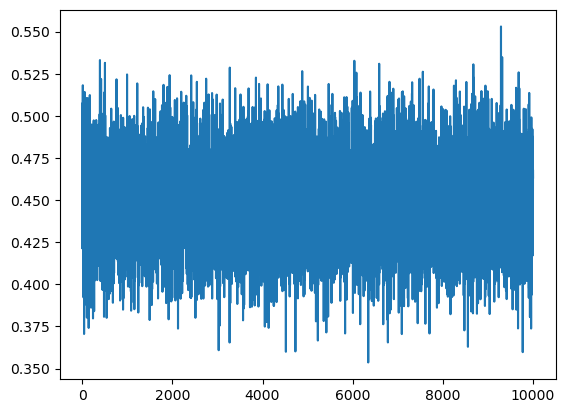

In [25]:
loss_values = []
# SGD, i.e. do minibatches
# apply GD in a loop
h = 0.01 # step size
for step in tqdm.tqdm(range(10000)):
    C.grad = None
    
    # minibatch selection
    batch_idx = torch.randint(0, len(Xall), (256,))

    # compute dot products
    dots = C[Xall[batch_idx]].prod(dim=1).sum(dim=1)

    # apply sigmoid function to get an output in (0, 1)
    pred = F.sigmoid(dots)

    # loss = ((pred - Yall[batch_idx])**2).mean().sqrt() # L2 error
    loss = (pred - Yall[batch_idx]).abs().mean() # L1 error
    # loss = F.cross_entropy(dots, Yall[batch_idx])
    loss_values.append(loss.item())
    # if step % 100 == 0:
    #     print(loss.item())

    loss.backward()
    C.data -= h*C.grad
    
    # # Center
    # if step % 100 ==0:
    #     C.data -= C.mean(axis=0, keepdims=True)

plt.plot(loss_values)

In [26]:
C = torch.load('data/word2vec-2026-04-03.pt')

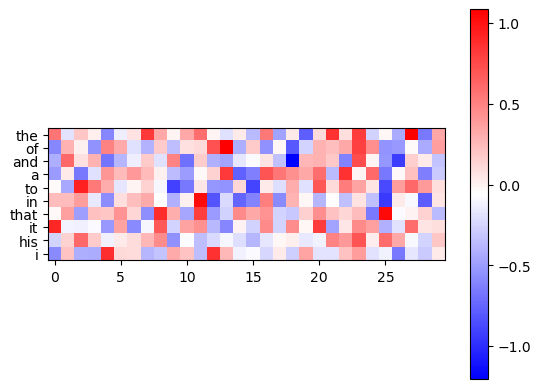

In [27]:
# investigate the embedding!
from collections import Counter
cnt = Counter(all_words_lower)

words_to_plot = [word for word, count in cnt.most_common(10)]
plt.imshow(torch.stack([C[w_to_i[word]] - C.mean(axis=0) for word in words_to_plot]).detach().numpy(), cmap = 'bwr')
plt.yticks(range(len(words_to_plot)), words_to_plot)
plt.colorbar()

In [28]:
# for each dimension, look at the top- and bottom-ranked words
def list_top_and_bottom(C, idx=0, num = 10):
    I = torch.argsort(C[:,idx])[:num] # sorts in ascending order, i.e. lowest first
    J = torch.argsort(C[:,idx], descending=True)[:num] # descending sort, highest first
    print(f'coordinate {idx}:')
    print('         highest         lowest')
    for k, (i, j) in enumerate(zip(I, J)):
        print(f'rank {k}: {i_to_w[j.item()]:<15} {i_to_w[i.item()]:<15}')

In [29]:
for idx in range(30):
    list_top_and_bottom(C, idx=idx, num=2)

coordinate 0:
         highest         lowest
rank 0: noon            caulk          
rank 1: cognisable      dreadful       
coordinate 1:
         highest         lowest
rank 0: housekeepers    second         
rank 1: ventilated      shipkeepers    
coordinate 2:
         highest         lowest
rank 0: gown            pluck          
rank 1: rebellion       universal      
coordinate 3:
         highest         lowest
rank 0: friends         expresses      
rank 1: blighted        exhaustive     
coordinate 4:
         highest         lowest
rank 0: centrally       wavings        
rank 1: dam             prophets       
coordinate 5:
         highest         lowest
rank 0: shuts           estimated      
rank 1: pea             comprehended   
coordinate 6:
         highest         lowest
rank 0: scorning        ark            
rank 1: assure          administering  
coordinate 7:
         highest         lowest
rank 0: furthest        pupils         
rank 1: blank           warmed  

In [115]:
from sklearn.decomposition import PCA

pca = PCA(2)
reduced_dim = pca.fit_transform(C.detach().numpy())

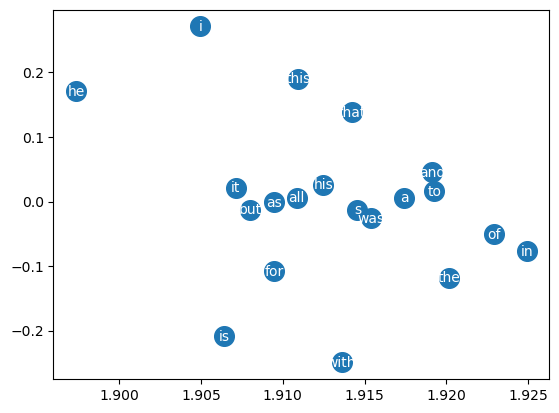

In [116]:
for word, count in cnt.most_common(20):
    i = w_to_i[word]
    plt.scatter(reduced_dim[i,0], reduced_dim[i,1], s=200, color='tab:blue')
    plt.text(reduced_dim[i,0], reduced_dim[i,1], word, va='center',ha='center', color='white')

In [51]:
def vector(word):
    return C[w_to_i[word]]

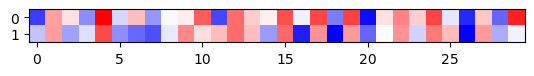

In [117]:
v1 = vector('king') #- vector('man') + vector('woman')
v2 = vector('queen')

plt.imshow(torch.stack([v1, v2]).detach().numpy(), cmap = 'bwr')

In [118]:
# we can use this word embedding to try and do prediction
# save it to use later or in another script without having to re-train
torch.save(C.detach(), 'data/word2vec-2026-04-03.pt')


In [124]:
inputs = torch.tensor([1, -1],dtype=torch.float)
targets = torch.tensor([1, 1],dtype=torch.float)
F.cross_entropy(inputs, targets)

tensor(2.2539)